In [6]:
!pip install transformers
!pip install torch
!pip install pandas

# 1. Financial Phrasebank

Subir el archivo ZIP

In [9]:
from google.colab import files
uploaded = files.upload()

Saving FinancialPhraseBank-v1.0.zip to FinancialPhraseBank-v1.0.zip


Descomprimir el archivo ZIP

In [10]:
from zipfile import ZipFile

zip_path = "/content/FinancialPhraseBank-v1.0.zip"
extract_to = "/content/FinancialPhraseBank"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Archivo descomprimido en:", extract_to)

✅ Archivo descomprimido en: /content/FinancialPhraseBank


Ver qué archivos se extrajeron

In [12]:
import os

# Listar archivos dentro del directorio extraído
for root, dirs, files in os.walk("/content/FinancialPhraseBank"):
    for file in files:
        print(os.path.join(root, file))

/content/FinancialPhraseBank/__MACOSX/FinancialPhraseBank-v1.0/._License.txt
/content/FinancialPhraseBank/__MACOSX/FinancialPhraseBank-v1.0/._README.txt
/content/FinancialPhraseBank/FinancialPhraseBank-v1.0/Sentences_66Agree.txt
/content/FinancialPhraseBank/FinancialPhraseBank-v1.0/Sentences_AllAgree.txt
/content/FinancialPhraseBank/FinancialPhraseBank-v1.0/Sentences_75Agree.txt
/content/FinancialPhraseBank/FinancialPhraseBank-v1.0/README.txt
/content/FinancialPhraseBank/FinancialPhraseBank-v1.0/Sentences_50Agree.txt
/content/FinancialPhraseBank/FinancialPhraseBank-v1.0/License.txt


Cargar Sentences_AllAgree.txt

In [13]:
file_path = "/content/FinancialPhraseBank/FinancialPhraseBank-v1.0/Sentences_AllAgree.txt"

data = []
with open(file_path, "r", encoding="latin-1") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        phrase, sentiment = line.rsplit("@", 1)
        data.append({"text": phrase.strip(), "label": sentiment.strip()})

df = pd.DataFrame(data)
df.head()

,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


Cargar el modelo FinBERT y el tokenizer

In [14]:
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

model_name = "ProsusAI/finbert"

tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Device set to use cpu


Probar con algunas frases (debug rápido)

In [15]:
sample_texts = df['text'].tolist()[:5]

for text in sample_texts:
    result = nlp(text)[0]
    print(f"📝 Frase: {text}")
    print(f"➡️ Sentimiento: {result['label']} (score: {result['score']:.4f})")
    print("---")

📝 Frase: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
➡️ Sentimiento: neutral (score: 0.8857)
---
📝 Frase: For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .
➡️ Sentimiento: positive (score: 0.9482)
---
📝 Frase: In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .
➡️ Sentimiento: positive (score: 0.9570)
---
📝 Frase: Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales .
➡️ Sentimiento: positive (score: 0.9524)
---
📝 Frase: Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales .
➡️ Sentimiento: positive (score: 0.9550)
---


Aplicar FinBERT a todo el dataset (puede demorar unos minutos)

In [16]:
df['predicted_label'] = df['text'].apply(lambda x: nlp(x)[0]['label'])
df['predicted_score'] = df['text'].apply(lambda x: nlp(x)[0]['score'])

Comparar etiquetas reales vs. predichas (opcional)

In [17]:
from sklearn.metrics import classification_report

print(classification_report(df['label'], df['predicted_label']))

              precision    recall  f1-score   support

    negative       0.91      0.98      0.94       303
     neutral       1.00      0.97      0.98      1391
    positive       0.95      0.98      0.96       570

    accuracy                           0.97      2264
   macro avg       0.95      0.98      0.96      2264
weighted avg       0.97      0.97      0.97      2264



*   Precision: De todas las veces que el modelo predijo esa clase, ¿cuántas veces acertó?

*   Recall: De todas las veces que la clase real era esa, ¿cuántas veces la encontró?

*   F1-score: Promedio entre precision y recall (cuanto más alto, mejor).

*   Support: Cantidad de frases de esa clase en el dataset.

*   Accuracy (precisión global): El 97% de las frases fueron clasificadas correctamente.

*   Macro avg: Promedio simple entre clases.

*   Weighted avg: Promedio ponderado por el número de ejemplos por clase





**Interpretación:**
- FinBERT funcionó muy bien en este dataset.
- Neutral fue la clase más fácil de clasificar.
- Negative tuvo un poco menos de precisión (probablemente por ser la menos representada: solo 303 frases).
- En general, muy alta exactitud (97%) y muy buenos puntajes en todas las métricas.

Gráfico de barras: distribución de etiquetas verdaderas vs. predichas

<ipython-input-18-a1b54e16f6ca>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, ax=axes[0], palette="pastel")
<ipython-input-18-a1b54e16f6ca>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='predicted_label', data=df, ax=axes[1], palette="muted")


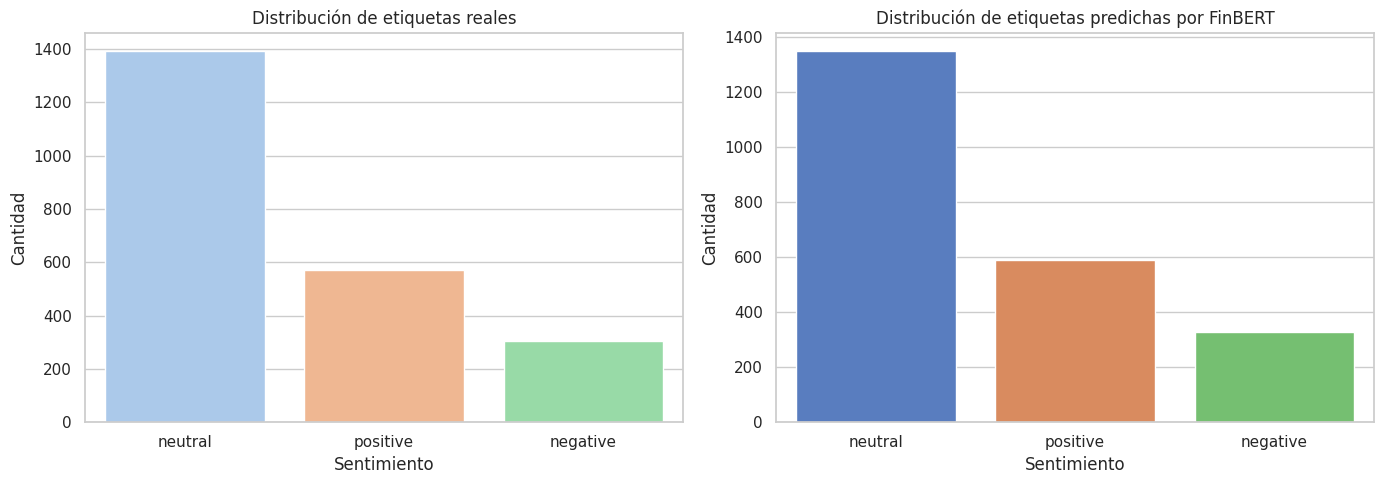

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general
sns.set(style="whitegrid")

# Crear gráficos de barras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución real
sns.countplot(x='label', data=df, ax=axes[0], palette="pastel")
axes[0].set_title("Distribución de etiquetas reales")
axes[0].set_ylabel("Cantidad")
axes[0].set_xlabel("Sentimiento")

# Distribución predicha
sns.countplot(x='predicted_label', data=df, ax=axes[1], palette="muted")
axes[1].set_title("Distribución de etiquetas predichas por FinBERT")
axes[1].set_ylabel("Cantidad")
axes[1].set_xlabel("Sentimiento")

plt.tight_layout()
plt.show()

Matriz de confusión

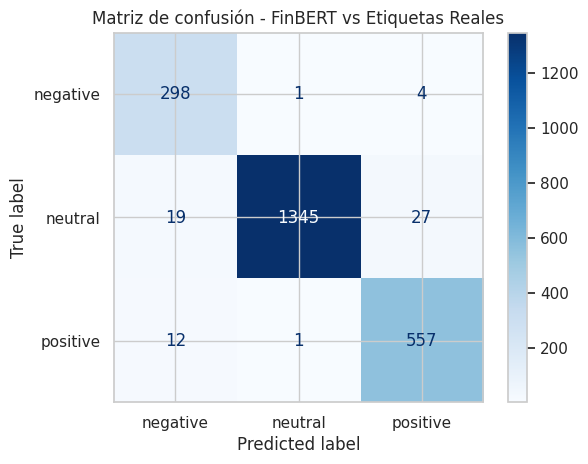

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Crear matriz
labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(df['label'], df['predicted_label'], labels=labels)

# Mostrar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión - FinBERT vs Etiquetas Reales")
plt.show()

# Practical Case

Instalar las librerías necesarias

In [20]:
!pip install pymupdf transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 70.7 MB/s eta 0:00:00


Subir el archivo PDF

In [21]:
from google.colab import files
uploaded = files.upload()

Saving Contrato_ejercicio.pdf to Contrato_ejercicio.pdf


📄 Extraer el texto del PDF con PyMuPDF

In [22]:
import fitz  # PyMuPDF

# Suponiendo que el archivo se llama 'Contrato_ejercicio.pdf'
file_name = "Contrato_ejercicio.pdf"

def extract_text_from_pdf(file_path):
    doc = fitz.open(file_path)
    text = ""
    for page in doc:
        text += page.get_text()
    return text

pdf_text = extract_text_from_pdf(file_name)
print("Texto extraído (primeros 1000 caracteres):")
print(pdf_text[:1000])  # mostrar una vista previa

Texto extraído (primeros 1000 caracteres):
ARRENDAMIENTO DE LOCAL COMERCIAL 
 
 
Conste por la suscripción del presente contrato de Arrendamiento o Alquiler del Local 
Comercial que celebran, de una parte ZAMORA QUISPE, MARÍA ELENA, 
identificada con DNI N.º 00000001, con domicilio real en Calle Los Cipreses N.º 123, 
Urb. Jardines del Sol, Distrito de San Martín de Porres, a quien en adelante se le 
denominará LA DUEÑA o ARRENDADORA; y de la otra parte, el señor 
VELÁSQUEZ MENDOZA, JULIO, identificado con DNI N.º 00000002, con domicilio 
en Mz. A Lt. 15, Conjunto Residencial Santa Clara, Distrito de Los Olivos, a quien 
en adelante se le denominará EL ARRENDATARIO o INQUILINO, bajo los 
siguientes términos: 
 
ANTECEDENTES 
 
 
PRIMERA: LA ARRENDADORA declara ser propietaria del inmueble ubicado en la 
Av. Los Laureles N.º 450, Mz. B Lt. 20, Urb. Villa Central, Distrito de 
Independencia, entre las avenidas Los Laureles y Alameda del Norte. 
 
 
SEGUNDA: LA ARRENDADORA deja constancia

Usar Hugging Face para resumir el texto

In [23]:
from transformers import pipeline

# Cargar el modelo de resumen
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

# Debido a la limitación de tokens, se recomienda dividir el texto
def summarize_text(text, max_chunk=1000):
    chunks = [text[i:i+max_chunk] for i in range(0, len(text), max_chunk)]
    summary = ""
    for chunk in chunks:
        summary_piece = summarizer(chunk, max_length=130, min_length=30, do_sample=False)[0]['summary_text']
        summary += summary_piece + "\n"
    return summary

executive_summary = summarize_text(pdf_text)
print("📋 Executive Summary:")
print(executive_summary)

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


📋 Executive Summary:
Arrendamiento o Alquiler del Local                 Comercial que celebran, de una parte ZAMORA QUISPE, MARÍA ELENA, y de la otra parte, el señor VELÁSQUEZ MENDOZA, JULIO.
La Alameda del Norte N.º 451, en buen estado de conservación y habitabilidad, con piso de cerámica tipo porcelanato. El presente contrato, LA ARRENDADORA se obliga a ceder el uso del local comercial, concerniente como local comerscial, a favor of EL  ARRENDATARIO, a título de alquiler. El monto de la renta pactada en la cláusula siguiente.
La renta será pago por mensualidades, realizándose el abono 11 de cada mes. El comprobante de pago deberá ser enviado por correo electrónico o entregado a LA ARRENDADORA dentro of las 24 horas posteriores a cada depósito.
El Código Civil está obligado a pagar puntualmente el monto de todos los servicios inherentes al bien tales como agua y luz eléctrica, parques y jardines with el impuesto del Patrimonio. Así mismo, EL ARRENDATARIO esta obligado toda la entrega 

✅ Refinar el summary

Instalar dependencias

In [24]:
!pip install transformers language-tool-python spacy
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 44.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Limpiar texto con regex + SpaCy

In [25]:
import re
import spacy

# Cargar modelo de español
nlp = spacy.load("es_core_news_sm")

def clean_text(raw_text):
    # Eliminar enlaces y textos en inglés erróneos
    cleaned = re.sub(r'http\S+|www\S+|click here.*|IO\.IO\.io.*', '', raw_text, flags=re.IGNORECASE)
    # Eliminar palabras sin sentido frecuentes
    cleaned = re.sub(r'\bpurposefully\S*|\bishlyindubitable\b', '', cleaned)
    # Quitar espacios y saltos de línea redundantes
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

Corregir ortografía y gramática con LanguageTool

In [26]:
import language_tool_python

def correct_grammar(text):
    tool = language_tool_python.LanguageTool('es')
    matches = tool.check(text)
    corrected = language_tool_python.utils.correct(text, matches)
    return corrected

Reescribir el texto con modelo Hugging Face (opcional pero recomendado)

In [27]:
from transformers import pipeline

# Cargar modelo generador de resumen en español o multilingüe
rephraser = pipeline("summarization", model="facebook/bart-large-cnn")

def rephrase_text(text):
    # dividir si es largo
    chunks = [text[i:i+1024] for i in range(0, len(text), 1024)]
    final_text = ""
    for chunk in chunks:
        summary = rephraser(chunk, max_length=150, min_length=40, do_sample=False)[0]['summary_text']
        final_text += summary + "\n"
    return final_text


Device set to use cpu


Ejecutar el pipeline completo

In [29]:
!sudo apt-get update
!sudo apt-get install openjdk-17-jdk -y
!java -version  # Confirmamos que ahora es 17

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,765 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,017 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-upda

In [30]:
!pip install transformers language-tool-python spacy
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 97.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [32]:
raw_summary = """
📋 Executive Summary:
Arrendamiento o Alquiler del Local                 Comercial que celebran, de una parte ZAMORA QUISPE, MARÍA ELENA, y de la otra parte, el señor VELÁSQUEZ MENDOZA, JULIO.
La Alameda del Norte N.º 451, en buen estado de conservación y habitabilidad, con piso de cerámica tipo porcelanato. El presente contrato, LA ARRENDADORA se obliga a ceder el uso del local comercial, concerniente como local comerscial, a favor of EL  ARRENDATARIO, a título de alquiler. El monto de la renta pactada en la cláusula siguiente.
La renta será pago por mensualidades, realizándose el abono 11 de cada mes. El comprobante de pago deberá ser enviado por correo electrónico o entregado a LA ARRENDADORA dentro of las 24 horas posteriores a cada depósito.
El Código Civil está obligado a pagar puntualmente el monto de todos los servicios inherentes al bien tales como agua y luz eléctrica, parques y jardines with el impuesto del Patrimonio. Así mismo, EL ARRENDATARIO esta obligado toda la entrega de las llaves  del alquiler.
El arrendatario se obliga a destinar el bien exclusivamente para FARMACIA. El bien deberá cruzar previo aviso por escrito, con una anticipación no de 7 días.
EL ARRENDATARIO no podrá ceder a terceros el bien material bajo ningún título, ni subarrendar, total o parcial. En caso de incumplimiento de lo estipulado en la cláusula séptima, EL ARRENTARARIO deberá pagar en calidad de penalidad a 10 dólares.
El mencionado depósito en garantía le será devuelto a EL ARRENDATARIO sin  vencimiento del contrato, una vez verificado el estado de conservación. El pago por mes  purposefullyadelantado de Setiembre del 2024 por la suma de S/ 1400 MIL CUATROCIENTOS  purposefullySOLES.
Son causales de resolución del contrato el incumplimiento las causales establecidas en el art. 1697° del Código Civil siempre que no se encuentren comprendidas su tratamiento especial en el presente contrato. De conformidad al art. 5° de la Ley 30201.
LA ARRENDADORA y EL ARR ENDATARIO declaran expresamente y de manera ishlyindubitable, que se someten a los efectos that contiene de la Ley 30933. En ese sentido, se produce el vencimiento del plazo del presente contrato de arrendamiento.
VIGÉSIMO CUARTA: En lo previsto de las partes del presente contrato ambas partes  someten a lo establecido by las normas del Código Civil. Así mismo LA ARRENDADORA o dueña del bien, deja  purposefully constancia que puede ampararse.
IO.IO.io is a web site that allows users to share photos and other information. The site is open to the public and can be accessed by anyone by clicking here. Click here to visit.
"""

cleaned = clean_text(raw_summary)
corrected = correct_grammar(cleaned)
final_summary = rephrase_text(corrected)

print("✅ Executive Summary corregido y mejorado:")
print(final_summary)

Your max_length is set to 150, but your input_length is only 100. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=50)


✅ Executive Summary corregido y mejorado:
La renta será pago por mensualidades, realizándose el abono 11 de cada mes. El Código Civil está obligado a pagar puntualmente el monto de todos los servicios inherentes al bien tales como agua y luz eléctrica.
El bien deberá cruzar previo aviso por escrito, con una anticipación no de 7 días. El mencionado depósito en garantía le será devuelto a EL ARRENDATARIO sin vencimiento del contrato. El pago por mes de setiembre del 2024 por la suma de S/ 1400 MIL CUATROCIENTOS.
VigesimOCUARTA: En lo previsto de las partes del presente contrato ambas partes someten a lo establecido by las normas del Código Civil. Así mismo LA ARRENDADORA o dueña del bien, deja constancia que puede ampararse.



💡 Bonus (Additional Evaluation)

**Named Entity Recognition (NER)**

*   Te ayuda a identificar personas, lugares, montos y fechas clave en el contrato automáticamente.

In [36]:
from transformers import pipeline
from collections import defaultdict

# Paso 1: Cargar modelo de NER en español
ner_pipeline = pipeline("ner", model="mrm8488/bert-spanish-cased-finetuned-ner", grouped_entities=True)

# Paso 2: Ejecutar NER sobre el texto (puede ser `raw_summary` o `cleaned`)
entities = ner_pipeline(raw_summary[:1000])

# Paso 3: Clasificar entidades
entidades = defaultdict(set)

for e in entities:
    label = e["entity_group"]
    word = e["word"].replace("##", "")  # elimina artefactos BERT como ##ENA

    # Ignorar ruido como "📋 Executive Summary"
    if "Executive Summary" in word or "📋" in word:
        continue

    # Normalizar categoría: combinar Código + Civil como LEY
    if word.lower() == "código":
        maybe_next = [ent["word"].replace("##", "") for ent in entities if ent["word"].lower() == "civil"]
        if "Civil" in maybe_next:
            entidades["LEY"].add("Código Civil")
            continue

    # Agrupar y guardar limpiamente
    if label in ["PER", "ORG", "LOC", "MISC"]:
        entidades[label].add(word)

# Paso 4: Mostrar resumen limpio
etiquetas_legibles = {
    "PER": "Personas (PER)",
    "LOC": "Ubicación (LOC)",
    "ORG": "Organizaciones / Roles (ORG)",
    "MISC": "Conceptos legales (MISC)",
    "LEY": "Leyes aplicables (LEY)"
}

print("🧠 Entidades extraídas del contrato:\n")

for tipo, valores in etiquetas_legibles.items():
    if tipo in entidades:
        print(f"**{valores}**:")
        for val in sorted(entidades[tipo]):
            print(f"- {val}")
        print()

Some weights of the model checkpoint at mrm8488/bert-spanish-cased-finetuned-ner were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


🧠 Entidades extraídas del contrato:

**Personas (PER)**:
- ENA
- JULIO
- VELÁSQUEZ MENDOZA
- ZAMORA QUISPE

**Ubicación (LOC)**:
- La Alameda del Norte

**Organizaciones / Roles (ORG)**:
- EL ARRENDATARIO
- LA ARRENDADORA

**Conceptos legales (MISC)**:
- Alquiler
- Civil
- Local Comercial
- Patrimonio

**Leyes aplicables (LEY)**:
- Código Civil



**Zero-Shot Classification**


*   Usa zero-shot-classification para etiquetar partes del contrato automáticamente



In [37]:
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")

candidate_labels = ["Obligaciones", "Penalidades", "Duración", "Garantía", "Uso del local", "Resolución de contrato"]

result = classifier(raw_summary, candidate_labels, multi_label=True)

for label, score in zip(result['labels'], result['scores']):
    print(f"{label}: {score:.2f}")

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


Resolución de contrato: 0.92
Duración: 0.85
Uso del local: 0.85
Obligaciones: 0.82
Garantía: 0.77
Penalidades: 0.73
